## 📦 1. Configuración del Entorno e Importación de Librerías

In [11]:
# Configuración de warnings y display
import warnings
warnings.filterwarnings('ignore')

# Librerías de datos
import numpy as np
import pandas as pd

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, brier_score_loss, roc_curve
from sklearn.calibration import calibration_curve
import xgboost as xgb

# Fútbol - Visualización y datos
from mplsoccer import Pitch, VerticalPitch

# Módulos locales del proyecto
from utils import (
    calculate_distance_to_goal,
    calculate_angle_to_goal,
    extract_shot_features,
    create_shot_type_features,
    create_assist_features,
    generate_synthetic_shots,
    get_xg_baseline_by_zone
)
from expected_goals import ExpectedGoalsModel, XGAnalyzer, train_xg_pipeline

# Configuración de visualización
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

# Semilla para reproducibilidad
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✅ Librerías importadas correctamente")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"XGBoost version: {xgb.__version__}")

✅ Librerías importadas correctamente
NumPy version: 1.26.4
Pandas version: 2.3.3
XGBoost version: 2.1.3


## 📊 2. Generación y Exploración de Datos

Para este proyecto utilizaremos datos sintéticos que simulan las características de tiros reales. Esto permite demostrar el funcionamiento del modelo sin depender de fuentes externas.

> **Nota:** El modelo puede ser fácilmente adaptado para usar datos de StatsBomb o cualquier otra fuente.

In [12]:
# Generar datos sintéticos de tiros
N_SHOTS = 3000

print(f"Generando {N_SHOTS} tiros sintéticos...")
df_shots = generate_synthetic_shots(n_shots=N_SHOTS, random_state=RANDOM_STATE)

# Aplicar feature engineering adicional
df_shots = create_shot_type_features(df_shots)
df_shots = create_assist_features(df_shots)

print(f"\n📊 Dataset generado: {df_shots.shape[0]} filas, {df_shots.shape[1]} columnas")
print(f"\n🎯 Distribución de resultados:")
print(f"   - Goles: {df_shots['goal'].sum()} ({df_shots['goal'].mean()*100:.1f}%)")
print(f"   - No gol: {(1-df_shots['goal']).sum()} ({(1-df_shots['goal'].mean())*100:.1f}%)")

df_shots.head(10)

Generando 3000 tiros sintéticos...

📊 Dataset generado: 3000 filas, 24 columnas

🎯 Distribución de resultados:
   - Goles: 353 (11.8%)
   - No gol: 2647 (88.2%)


,x,y,shot_type,body_part,pass_type,distance_to_goal,angle_to_goal,is_central,in_box,angle_distance_ratio,zone,goal,true_xg,is_penalty,is_free_kick,is_open_play,is_corner,is_header,is_right_foot,is_left_foot,assisted_throughball,assisted_cross,assisted_cutback,assisted_pullback
0,114.3713,31.7631,Penalty,Right Foot,Ground Pass,9.9764,28.3287,True,True,2.5809,left,1,0.7600,1,0,0,0,0,1,0,0,0,0,0
1,113.4323,31.0825,Corner,Left Foot,Ground Pass,11.0750,26.2261,True,True,2.1719,left,0,0.0503,0,0,0,1,0,0,1,0,0,0,0
2,112.7379,20.8053,Open Play,Right Foot,Ground Pass,20.5225,8.1598,False,False,0.3791,far_left,0,0.0115,0,0,1,0,0,1,0,0,0,0,0
3,108.9105,23.1370,Corner,Right Foot,None,20.1826,12.7730,False,False,0.6030,far_left,0,0.0182,0,0,0,1,0,1,0,0,0,0,0
4,118.9925,27.5602,Penalty,Right Foot,Ground Pass,12.4805,3.3005,False,True,0.2448,left,1,0.7600,1,0,0,0,0,1,0,0,0,0,0
5,108.4538,48.8736,Open Play,Left Foot,Cross,14.5621,25.2271,True,True,1.6211,right,0,0.0427,0,0,1,0,0,0,1,0,1,0,0
6,115.9874,34.2814,Open Play,Left Foot,Cut Back,6.9859,44.3802,True,True,5.5573,left,0,0.1009,0,0,1,0,0,0,1,0,0,1,0
7,111.0086,36.8926,Free Kick,Right Foot,Cross,9.5132,43.9945,True,True,4.1847,left,0,0.0897,0,1,0,0,0,1,0,0,1,0,0
8,112.9141,59.0513,Open Play,Head,Ground Pass,20.3264,8.1230,False,False,0.3809,far_right,0,0.0100,0,0,1,0,1,0,0,0,0,0,0
9,116.9036,59.4251,Penalty,Right Foot,None,19.6703,3.8207,False,False,0.1848,far_right,1,0.7600,1,0,0,0,0,1,0,0,0,0,0


In [13]:
# Resumen estadístico de las features principales
print("📈 Estadísticas descriptivas de features clave:\n")
df_shots[['x', 'y', 'distance_to_goal', 'angle_to_goal', 'goal']].describe().round(2)

📈 Estadísticas descriptivas de features clave:



,x,y,distance_to_goal,angle_to_goal,goal
count,3000.0000,3000.0000,3000.0000,3000.0000,3000.0000
mean,111.8500,40.1800,15.5500,26.5300,0.1200
std,4.7600,14.6600,7.9000,24.1700,0.3200
min,91.8800,5.0000,0.5500,0.0800,0.0000
25%,108.9100,30.1600,9.6500,9.0000,0.0000
50%,112.5700,40.2300,14.2300,20.0500,0.0000
75%,115.5500,50.1100,20.3300,35.7700,0.0000
max,119.9200,75.0000,40.3000,176.1400,1.0000


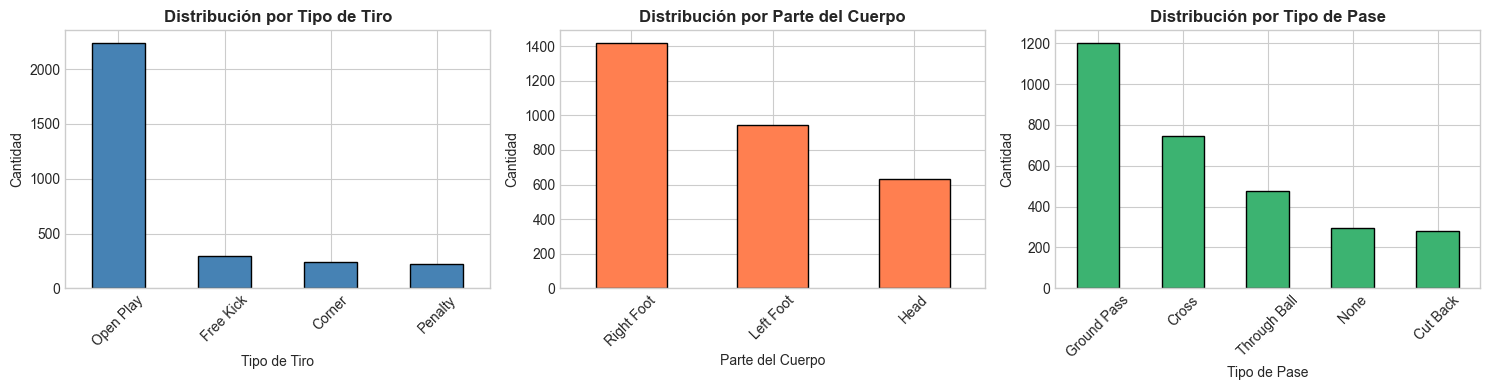

In [14]:
# Distribución de tipos de tiro
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Tipo de tiro
df_shots['shot_type'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Distribución por Tipo de Tiro', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Tipo de Tiro')
axes[0].set_ylabel('Cantidad')
axes[0].tick_params(axis='x', rotation=45)

# Parte del cuerpo
df_shots['body_part'].value_counts().plot(kind='bar', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('Distribución por Parte del Cuerpo', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Parte del Cuerpo')
axes[1].set_ylabel('Cantidad')
axes[1].tick_params(axis='x', rotation=45)

# Tipo de pase
df_shots['pass_type'].value_counts().plot(kind='bar', ax=axes[2], color='mediumseagreen', edgecolor='black')
axes[2].set_title('Distribución por Tipo de Pase', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Tipo de Pase')
axes[2].set_ylabel('Cantidad')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('figures/distribucion_categoricas.png', dpi=150, bbox_inches='tight')
plt.show()

## ⚽ 3. Visualización de Tiros en el Campo

Visualicemos la distribución de tiros en el campo de fútbol, diferenciando entre goles y no goles.

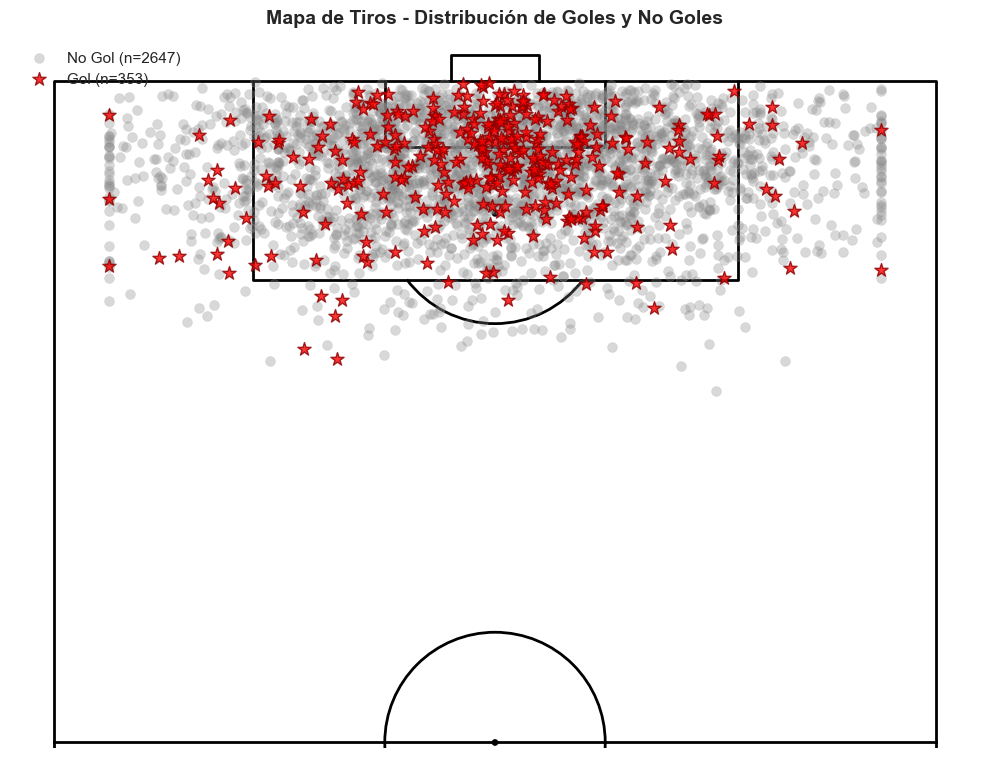


📍 Posición promedio de goles: (112.3, 39.4)
📍 Posición promedio de no goles: (111.8, 40.3)


In [15]:
# Crear figura con campo de fútbol vertical (solo mitad atacante)
pitch = VerticalPitch(
    pitch_type='statsbomb',
    half=True,
    goal_type='box',
    linewidth=2,
    line_color='black',
    pad_bottom=0.5
)

fig, ax = pitch.draw(figsize=(10, 10))

# Separar goles y no goles
goals = df_shots[df_shots['goal'] == 1]
no_goals = df_shots[df_shots['goal'] == 0]

# Plotear no goles (más transparentes)
pitch.scatter(
    no_goals['x'], no_goals['y'],
    ax=ax, s=50, c='gray', alpha=0.3,
    edgecolors='darkgray', linewidth=0.5,
    label=f'No Gol (n={len(no_goals)})'
)

# Plotear goles (más visibles)
pitch.scatter(
    goals['x'], goals['y'],
    ax=ax, s=100, c='red', alpha=0.8,
    edgecolors='darkred', linewidth=1,
    marker='*', label=f'Gol (n={len(goals)})'
)

ax.legend(loc='upper left', fontsize=11)
ax.set_title('Mapa de Tiros - Distribución de Goles y No Goles', 
             fontsize=14, fontweight='bold', pad=10)

plt.savefig('figures/mapa_tiros.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📍 Posición promedio de goles: ({goals['x'].mean():.1f}, {goals['y'].mean():.1f})")
print(f"📍 Posición promedio de no goles: ({no_goals['x'].mean():.1f}, {no_goals['y'].mean():.1f})")

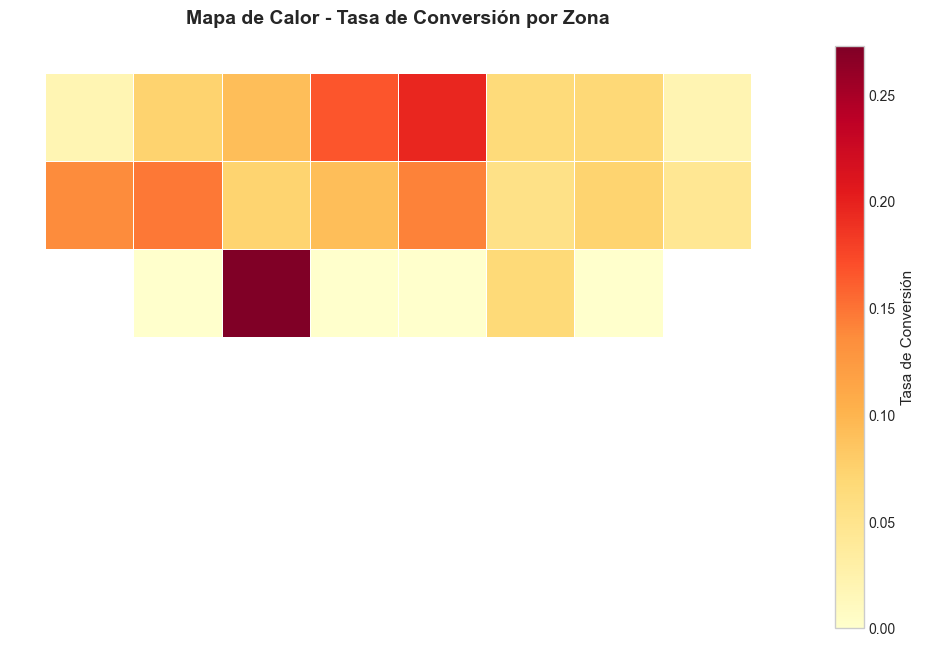

In [16]:
# Mapa de calor de probabilidad de gol por zona
pitch = VerticalPitch(
    pitch_type='statsbomb',
    half=True,
    linewidth=2,
    line_color='white'
)

fig, ax = pitch.draw(figsize=(10, 10))

# Crear heatmap de tasa de conversión
bin_statistic = pitch.bin_statistic(
    df_shots['x'], df_shots['y'], 
    values=df_shots['goal'],
    statistic='mean', 
    bins=(12, 8)
)

# Dibujar heatmap
pcm = pitch.heatmap(
    bin_statistic, ax=ax, 
    cmap='YlOrRd', 
    edgecolors='white',
    linewidth=0.5
)

# Añadir colorbar
cbar = fig.colorbar(pcm, ax=ax, shrink=0.6)
cbar.set_label('Tasa de Conversión', fontsize=11)

ax.set_title('Mapa de Calor - Tasa de Conversión por Zona', 
             fontsize=14, fontweight='bold', pad=10)

plt.savefig('figures/heatmap_conversion.png', dpi=150, bbox_inches='tight')
plt.show()

## 📐 4. Análisis de Features Geométricas

Las features más importantes en un modelo xG son las relacionadas con la geometría del tiro: **distancia** y **ángulo** al arco.

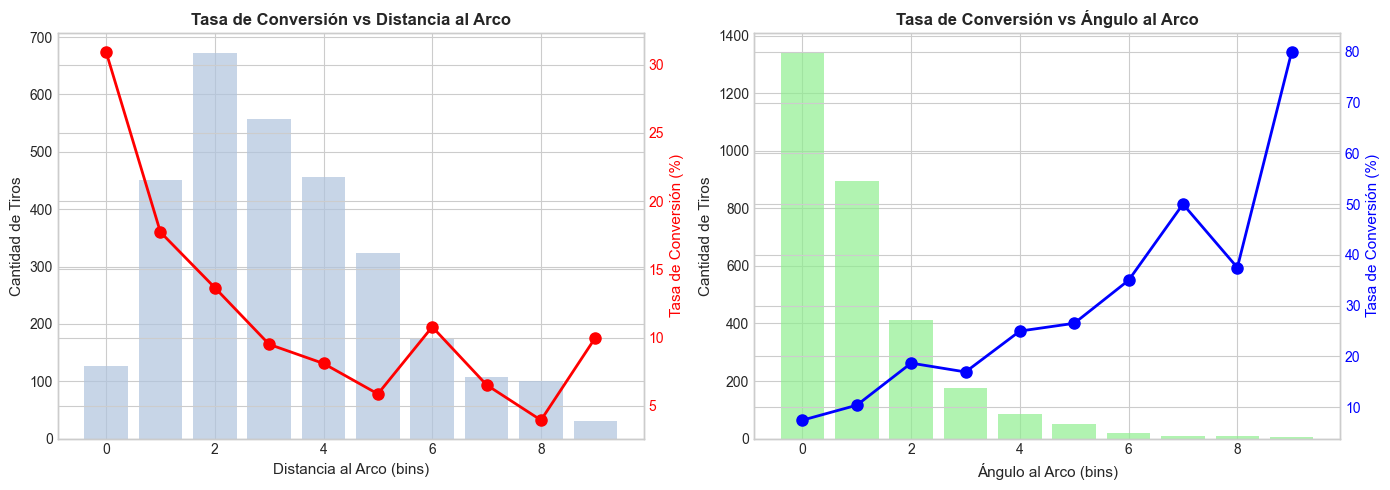

In [17]:
# Análisis de distancia vs probabilidad de gol
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distancia al arco
distance_bins = pd.cut(df_shots['distance_to_goal'], bins=10)
distance_stats = df_shots.groupby(distance_bins)['goal'].agg(['mean', 'count'])

ax1 = axes[0]
ax1_2 = ax1.twinx()

bars = ax1.bar(range(len(distance_stats)), distance_stats['count'], 
               color='lightsteelblue', alpha=0.7, label='Cantidad de tiros')
line = ax1_2.plot(range(len(distance_stats)), distance_stats['mean'] * 100, 
                  'ro-', linewidth=2, markersize=8, label='Tasa de conversión (%)')

ax1.set_xlabel('Distancia al Arco (bins)', fontsize=11)
ax1.set_ylabel('Cantidad de Tiros', fontsize=11)
ax1_2.set_ylabel('Tasa de Conversión (%)', fontsize=11, color='red')
ax1.set_title('Tasa de Conversión vs Distancia al Arco', fontsize=12, fontweight='bold')
ax1_2.tick_params(axis='y', labelcolor='red')

# Ángulo al arco
angle_bins = pd.cut(df_shots['angle_to_goal'], bins=10)
angle_stats = df_shots.groupby(angle_bins)['goal'].agg(['mean', 'count'])

ax2 = axes[1]
ax2_2 = ax2.twinx()

bars2 = ax2.bar(range(len(angle_stats)), angle_stats['count'], 
                color='lightgreen', alpha=0.7, label='Cantidad de tiros')
line2 = ax2_2.plot(range(len(angle_stats)), angle_stats['mean'] * 100, 
                   'bo-', linewidth=2, markersize=8, label='Tasa de conversión (%)')

ax2.set_xlabel('Ángulo al Arco (bins)', fontsize=11)
ax2.set_ylabel('Cantidad de Tiros', fontsize=11)
ax2_2.set_ylabel('Tasa de Conversión (%)', fontsize=11, color='blue')
ax2.set_title('Tasa de Conversión vs Ángulo al Arco', fontsize=12, fontweight='bold')
ax2_2.tick_params(axis='y', labelcolor='blue')

plt.tight_layout()
plt.savefig('figures/analisis_geometrico.png', dpi=150, bbox_inches='tight')
plt.show()

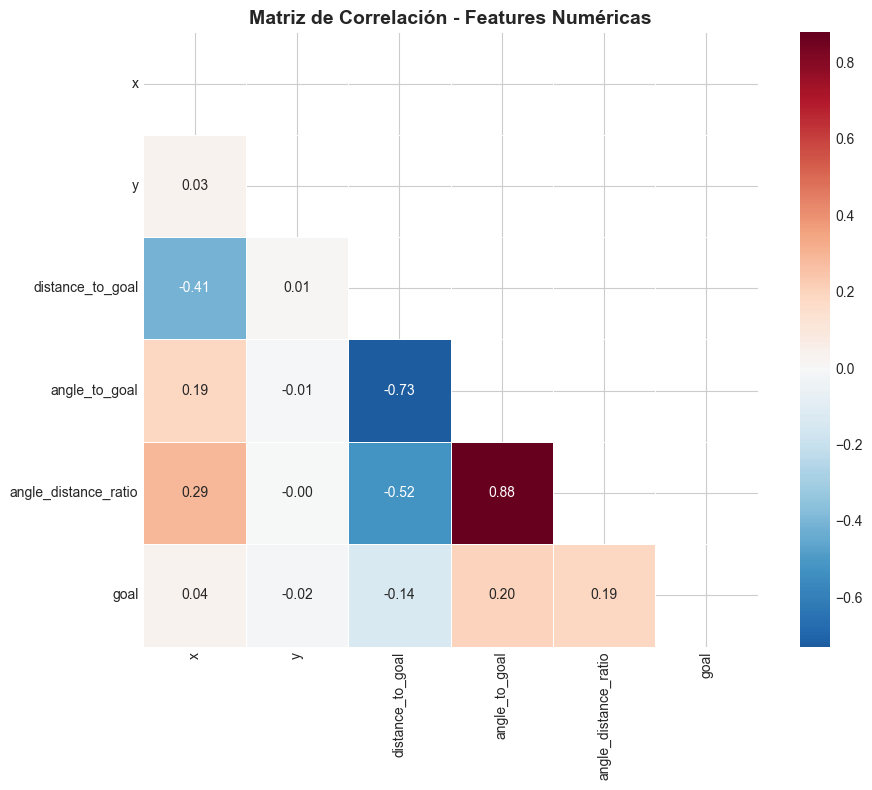

In [18]:
# Correlación entre features
numeric_cols = ['x', 'y', 'distance_to_goal', 'angle_to_goal', 
                'angle_distance_ratio', 'goal']

plt.figure(figsize=(10, 8))
correlation_matrix = df_shots[numeric_cols].corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

sns.heatmap(
    correlation_matrix, 
    mask=mask,
    annot=True, 
    cmap='RdBu_r', 
    center=0,
    fmt='.2f',
    square=True,
    linewidths=0.5
)

plt.title('Matriz de Correlación - Features Numéricas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/correlacion_features.png', dpi=150, bbox_inches='tight')
plt.show()

## 🤖 5. Entrenamiento del Modelo xG

Entrenaremos dos modelos:
1. **Logistic Regression** - Modelo base, interpretable
2. **XGBoost** - Modelo avanzado, mejor performance

### 5.1 División de Datos

In [19]:
# División train/test
train_df, test_df = train_test_split(
    df_shots, 
    test_size=0.2, 
    random_state=RANDOM_STATE,
    stratify=df_shots['goal']
)

print(f"📊 División de datos:")
print(f"   - Entrenamiento: {len(train_df)} tiros ({train_df['goal'].mean()*100:.1f}% goles)")
print(f"   - Test: {len(test_df)} tiros ({test_df['goal'].mean()*100:.1f}% goles)")

📊 División de datos:
   - Entrenamiento: 2400 tiros (11.8% goles)
   - Test: 600 tiros (11.8% goles)


### 5.2 Modelo 1: Logistic Regression

In [20]:
# Entrenar modelo de Regresión Logística
print("="*60)
print("MODELO 1: LOGISTIC REGRESSION")
print("="*60)

model_lr = ExpectedGoalsModel(
    model_type='logistic',
    random_state=RANDOM_STATE
)

model_lr.fit(train_df, target_col='goal', verbose=True)

MODELO 1: LOGISTIC REGRESSION
Entrenando modelo logistic...
Datos de entrenamiento: 2400 tiros
Tamaño de entrenamiento: 1920
Tamaño de validación: 480
Tasa de goles (train): 0.118
Features utilizadas: 15

=== Métricas de Validación ===
ROC-AUC: 0.9030
Brier Score: 0.1178


### 5.3 Modelo 2: XGBoost

In [21]:
# Entrenar modelo XGBoost
print("="*60)
print("MODELO 2: XGBOOST")
print("="*60)

model_xgb = ExpectedGoalsModel(
    model_type='xgboost',
    random_state=RANDOM_STATE,
    n_estimators=150,
    max_depth=6,
    learning_rate=0.1
)

model_xgb.fit(train_df, target_col='goal', verbose=True)

MODELO 2: XGBOOST
Entrenando modelo xgboost...
Datos de entrenamiento: 2400 tiros
Tamaño de entrenamiento: 1920
Tamaño de validación: 480
Tasa de goles (train): 0.118
Features utilizadas: 15

=== Métricas de Validación ===
ROC-AUC: 0.8470
Brier Score: 0.0755


## 📈 6. Evaluación y Comparación de Modelos

In [22]:
# Evaluar ambos modelos en conjunto de test
print("="*60)
print("EVALUACIÓN EN CONJUNTO DE TEST")
print("="*60)

# Métricas Logistic Regression
metrics_lr = model_lr.evaluate(test_df)
print("\n📊 Logistic Regression:")
for metric, value in metrics_lr.items():
    print(f"   {metric}: {value:.4f}")

# Métricas XGBoost
metrics_xgb = model_xgb.evaluate(test_df)
print("\n📊 XGBoost:")
for metric, value in metrics_xgb.items():
    print(f"   {metric}: {value:.4f}")

# Comparación
print("\n" + "="*60)
print("COMPARACIÓN DE MODELOS")
print("="*60)

comparison_df = pd.DataFrame({
    'Logistic Regression': metrics_lr,
    'XGBoost': metrics_xgb
}).round(4)

comparison_df['Mejor'] = comparison_df.apply(
    lambda x: 'XGBoost' if (x.name != 'brier_score' and x.name != 'log_loss' and x['XGBoost'] > x['Logistic Regression']) or 
              (x.name in ['brier_score', 'log_loss'] and x['XGBoost'] < x['Logistic Regression'])
              else 'Logistic Regression', axis=1
)

comparison_df

EVALUACIÓN EN CONJUNTO DE TEST

📊 Logistic Regression:
   roc_auc: 0.8848
   brier_score: 0.1125
   log_loss: 0.3889
   precision: 0.4712
   recall: 0.6901
   f1_score: 0.5600

📊 XGBoost:
   roc_auc: 0.8360
   brier_score: 0.0703
   log_loss: 0.2810
   precision: 0.7805
   recall: 0.4507
   f1_score: 0.5714

COMPARACIÓN DE MODELOS


,Logistic Regression,XGBoost,Mejor
roc_auc,0.8848,0.8360,Logistic Regression
brier_score,0.1125,0.0703,XGBoost
log_loss,0.3889,0.2810,XGBoost
precision,0.4712,0.7805,XGBoost
recall,0.6901,0.4507,Logistic Regression
f1_score,0.5600,0.5714,XGBoost


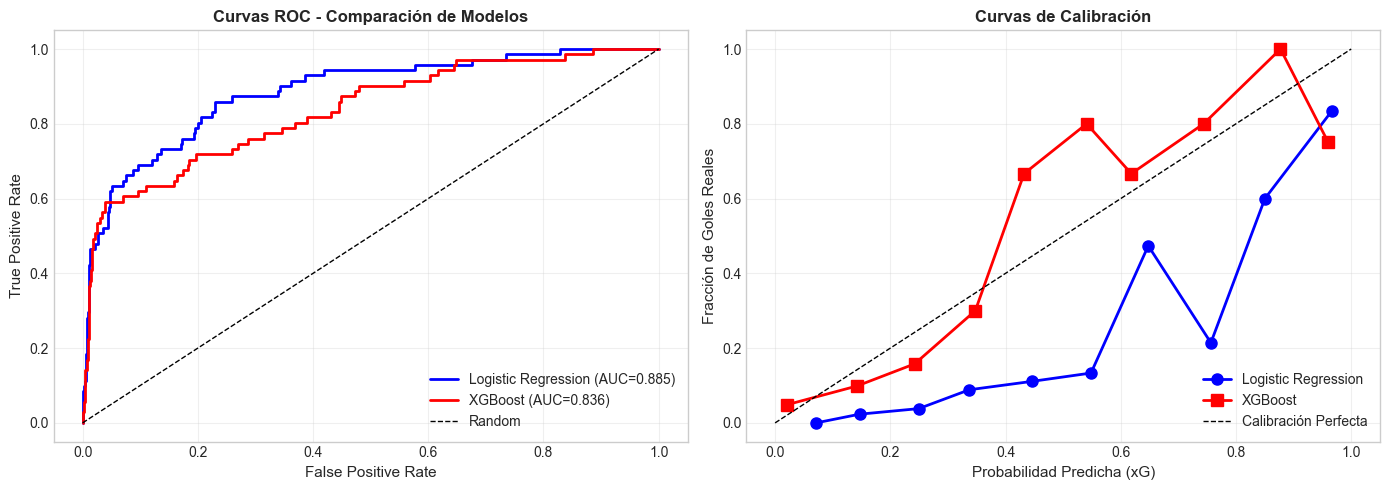

In [23]:
# Curvas ROC comparativas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predicciones
y_test = test_df['goal'].values
y_pred_lr = model_lr.predict_proba(test_df)
y_pred_xgb = model_xgb.predict_proba(test_df)

# ROC Curves
ax1 = axes[0]
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_lr)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_xgb)

ax1.plot(fpr_lr, tpr_lr, 'b-', linewidth=2, 
         label=f'Logistic Regression (AUC={metrics_lr["roc_auc"]:.3f})')
ax1.plot(fpr_xgb, tpr_xgb, 'r-', linewidth=2, 
         label=f'XGBoost (AUC={metrics_xgb["roc_auc"]:.3f})')
ax1.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')

ax1.set_xlabel('False Positive Rate', fontsize=11)
ax1.set_ylabel('True Positive Rate', fontsize=11)
ax1.set_title('Curvas ROC - Comparación de Modelos', fontsize=12, fontweight='bold')
ax1.legend(loc='lower right', fontsize=10)
ax1.grid(True, alpha=0.3)

# Calibration Curves
ax2 = axes[1]
prob_true_lr, prob_pred_lr = calibration_curve(y_test, y_pred_lr, n_bins=10)
prob_true_xgb, prob_pred_xgb = calibration_curve(y_test, y_pred_xgb, n_bins=10)

ax2.plot(prob_pred_lr, prob_true_lr, 'bo-', linewidth=2, markersize=8,
         label='Logistic Regression')
ax2.plot(prob_pred_xgb, prob_true_xgb, 'rs-', linewidth=2, markersize=8,
         label='XGBoost')
ax2.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Calibración Perfecta')

ax2.set_xlabel('Probabilidad Predicha (xG)', fontsize=11)
ax2.set_ylabel('Fracción de Goles Reales', fontsize=11)
ax2.set_title('Curvas de Calibración', fontsize=12, fontweight='bold')
ax2.legend(loc='lower right', fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/evaluacion_modelos.png', dpi=150, bbox_inches='tight')
plt.show()

## 🔍 7. Importancia de Features

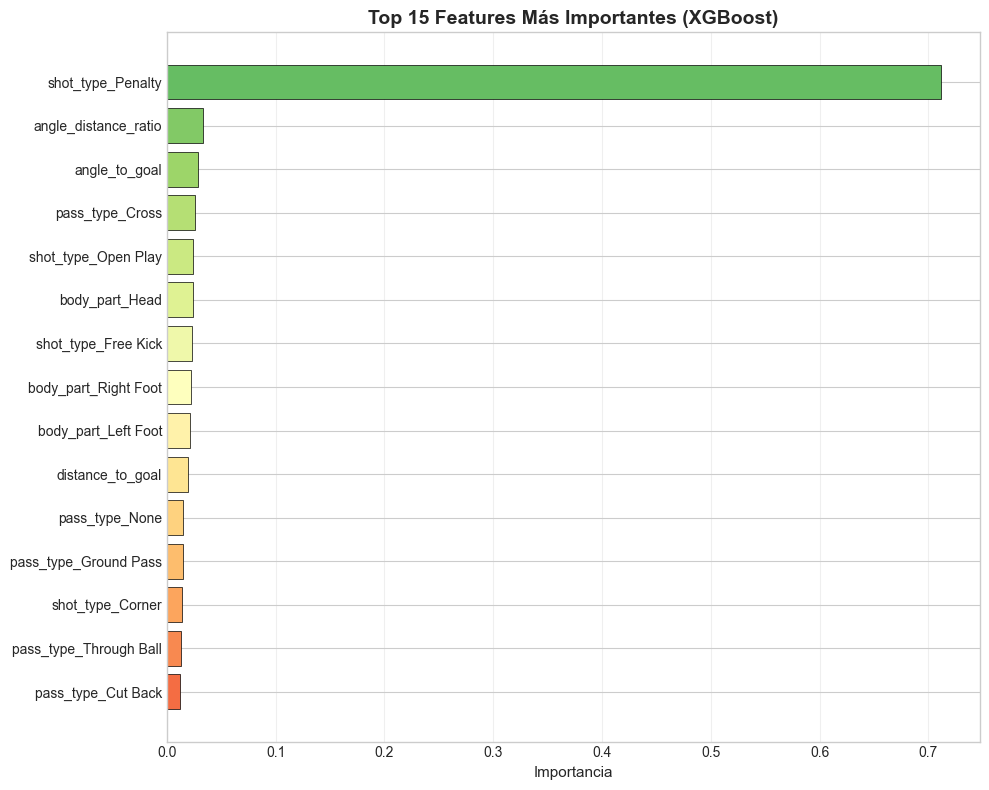


📊 Importancia de Features (XGBoost):


,feature,importance
6,shot_type_Penalty,0.7120
2,angle_distance_ratio,0.0328
1,angle_to_goal,0.0284
10,pass_type_Cross,0.0255
5,shot_type_Open Play,0.0237
7,body_part_Head,0.0237
4,shot_type_Free Kick,0.0233
9,body_part_Right Foot,0.0218
8,body_part_Left Foot,0.0211
0,distance_to_goal,0.0197


In [24]:
# Importancia de features en XGBoost
importance_df = model_xgb.get_feature_importance()

plt.figure(figsize=(10, 8))
top_n = 15
top_features = importance_df.head(top_n)

colors = plt.cm.RdYlGn(np.linspace(0.8, 0.2, top_n))

plt.barh(range(top_n), top_features['importance'].values[::-1], 
         color=colors[::-1], edgecolor='black', linewidth=0.5)
plt.yticks(range(top_n), top_features['feature'].values[::-1])

plt.xlabel('Importancia', fontsize=11)
plt.title(f'Top {top_n} Features Más Importantes (XGBoost)', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('figures/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Importancia de Features (XGBoost):")
importance_df.head(15)

## 🗺️ 8. Mapa de xG - Visualización del Modelo

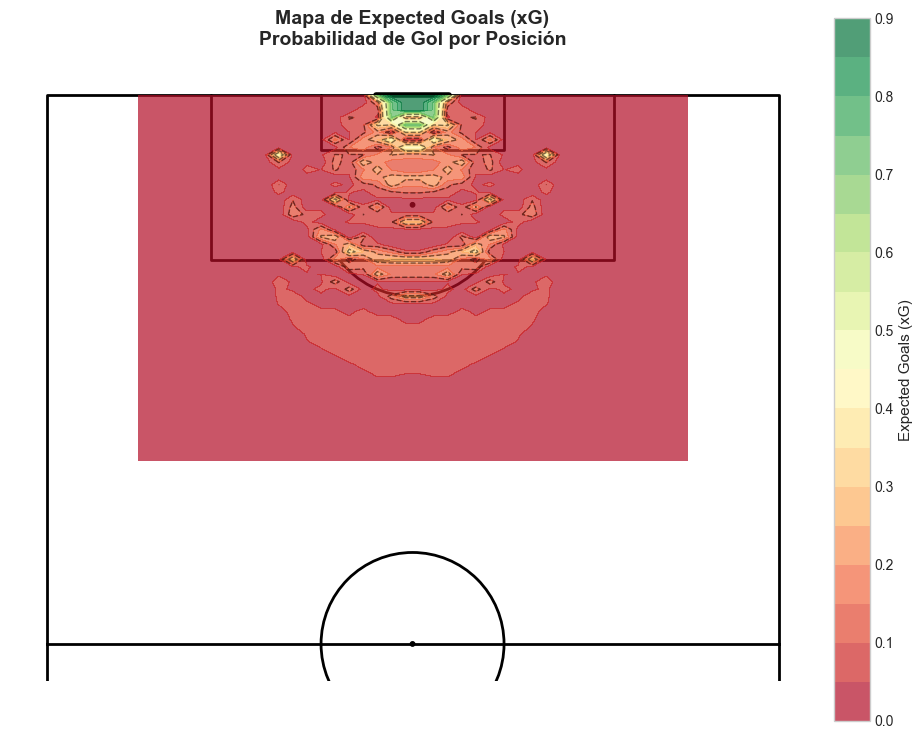

In [25]:
# Crear grid de predicciones xG
x_grid = np.linspace(80, 120, 50)
y_grid = np.linspace(10, 70, 40)
xx, yy = np.meshgrid(x_grid, y_grid)

# Crear DataFrame con grid
grid_df = pd.DataFrame({
    'x': xx.ravel(),
    'y': yy.ravel(),
    'shot_type': 'Open Play',
    'body_part': 'Right Foot',
    'pass_type': 'Ground Pass'
})

# Calcular features
grid_df = extract_shot_features(grid_df)
grid_df = create_shot_type_features(grid_df)
grid_df = create_assist_features(grid_df)

# Predecir xG
grid_df['xG'] = model_xgb.predict_proba(grid_df)

# Reshape para contour plot
xg_grid = grid_df['xG'].values.reshape(xx.shape)

# Visualizar
pitch = VerticalPitch(
    pitch_type='statsbomb',
    half=True,
    linewidth=2,
    line_color='black'
)

fig, ax = pitch.draw(figsize=(10, 12))

# Contour plot de xG
contour = ax.contourf(yy, xx, xg_grid, levels=20, cmap='RdYlGn', alpha=0.7)
cbar = fig.colorbar(contour, ax=ax, shrink=0.6, pad=0.02)
cbar.set_label('Expected Goals (xG)', fontsize=11)

# Añadir líneas de contorno
ax.contour(yy, xx, xg_grid, levels=[0.1, 0.2, 0.3, 0.5], colors='black', 
           linewidths=1, linestyles='dashed', alpha=0.5)

ax.set_title('Mapa de Expected Goals (xG)\nProbabilidad de Gol por Posición', 
             fontsize=14, fontweight='bold', pad=10)

plt.savefig('figures/mapa_xg.png', dpi=150, bbox_inches='tight')
plt.show()

## 📊 9. Validación Cruzada

In [26]:
# Validación cruzada del modelo XGBoost
print("="*60)
print("VALIDACIÓN CRUZADA - XGBoost")
print("="*60)

# Crear nuevo modelo para CV
model_cv = ExpectedGoalsModel(
    model_type='xgboost',
    random_state=RANDOM_STATE,
    n_estimators=150,
    max_depth=6
)

cv_results = model_cv.cross_validate(df_shots, n_folds=5, verbose=True)

VALIDACIÓN CRUZADA - XGBoost
Fold 1: AUC=0.8574, Brier=0.0680
Fold 2: AUC=0.8518, Brier=0.0731
Fold 3: AUC=0.8836, Brier=0.0550
Fold 4: AUC=0.8413, Brier=0.0745
Fold 5: AUC=0.8409, Brier=0.0739

=== Resultados CV (5 folds) ===
roc_auc: 0.8550 (+/- 0.0156)
brier_score: 0.0689 (+/- 0.0073)
log_loss: 0.2630 (+/- 0.0245)


## 💾 10. Guardar Modelo Final

In [27]:
# Guardar el mejor modelo (XGBoost)
import os

# Crear directorio para modelos si no existe
os.makedirs('models', exist_ok=True)

# Guardar modelo
model_xgb.save_model('models/xg_model_xgboost.joblib')

print("\n✅ Modelo guardado exitosamente")
print("   Ruta: models/xg_model_xgboost.joblib")

Modelo guardado en: models/xg_model_xgboost.joblib

✅ Modelo guardado exitosamente
   Ruta: models/xg_model_xgboost.joblib


In [28]:
# Ejemplo de carga del modelo
model_loaded = ExpectedGoalsModel.load_model('models/xg_model_xgboost.joblib')

# Verificar que funciona correctamente
test_prediction = model_loaded.predict_proba(test_df[:5])
print("\n🔄 Verificación del modelo cargado:")
print(f"   Predicciones de prueba: {test_prediction.round(3)}")


🔄 Verificación del modelo cargado:
   Predicciones de prueba: [0.012 0.006 0.038 0.895 0.002]


## 🎯 11. Ejemplo de Uso: Análisis de un Tiro

In [29]:
# Ejemplo interactivo: Calcular xG para un tiro específico
def analyze_shot(x, y, shot_type='Open Play', body_part='Right Foot', 
                 pass_type='Ground Pass', model=model_xgb):
    """
    Analiza un tiro y calcula su xG.
    """
    # Crear DataFrame con el tiro
    shot_df = pd.DataFrame({
        'x': [x],
        'y': [y],
        'shot_type': [shot_type],
        'body_part': [body_part],
        'pass_type': [pass_type]
    })
    
    # Calcular features
    shot_df = extract_shot_features(shot_df)
    shot_df = create_shot_type_features(shot_df)
    shot_df = create_assist_features(shot_df)
    
    # Predecir xG
    xg = model.predict_proba(shot_df)[0]
    
    # Mostrar resultados
    print("="*50)
    print("ANÁLISIS DE TIRO")
    print("="*50)
    print(f"\n📍 Posición: ({x}, {y})")
    print(f"📏 Distancia al arco: {shot_df['distance_to_goal'].values[0]:.2f} yards")
    print(f"📐 Ángulo visible: {shot_df['angle_to_goal'].values[0]:.2f}°")
    print(f"🦶 Parte del cuerpo: {body_part}")
    print(f"🏃 Tipo de jugada: {shot_type}")
    print(f"⚡ Tipo de pase previo: {pass_type}")
    print(f"\n🎯 Expected Goals (xG): {xg:.3f} ({xg*100:.1f}%)")
    print("="*50)
    
    return xg

# Ejemplos de diferentes situaciones
print("\n" + "="*60)
print("EJEMPLOS DE CÁLCULO DE xG")
print("="*60)

# Penal
print("\n🔴 PENAL:")
analyze_shot(108, 40, shot_type='Penalty', body_part='Right Foot', pass_type='None')

# Tiro desde el borde del área
print("\n🟡 TIRO DESDE BORDE DEL ÁREA:")
analyze_shot(100, 35, shot_type='Open Play', body_part='Right Foot', pass_type='Ground Pass')

# Cabezazo desde centro
print("\n🟢 CABEZAZO DESDE CENTRO:")
analyze_shot(110, 40, shot_type='Open Play', body_part='Head', pass_type='Cross')


EJEMPLOS DE CÁLCULO DE xG

🔴 PENAL:
ANÁLISIS DE TIRO

📍 Posición: (108, 40)
📏 Distancia al arco: 12.00 yards
📐 Ángulo visible: 36.87°
🦶 Parte del cuerpo: Right Foot
🏃 Tipo de jugada: Penalty
⚡ Tipo de pase previo: None

🎯 Expected Goals (xG): 0.913 (91.3%)

🟡 TIRO DESDE BORDE DEL ÁREA:
ANÁLISIS DE TIRO

📍 Posición: (100, 35)
📏 Distancia al arco: 20.62 yards
📐 Ángulo visible: 21.37°
🦶 Parte del cuerpo: Right Foot
🏃 Tipo de jugada: Open Play
⚡ Tipo de pase previo: Ground Pass

🎯 Expected Goals (xG): 0.045 (4.5%)

🟢 CABEZAZO DESDE CENTRO:
ANÁLISIS DE TIRO

📍 Posición: (110, 40)
📏 Distancia al arco: 10.00 yards
📐 Ángulo visible: 43.60°
🦶 Parte del cuerpo: Head
🏃 Tipo de jugada: Open Play
⚡ Tipo de pase previo: Cross

🎯 Expected Goals (xG): 0.221 (22.1%)


0.2213073

## 📝 12. Conclusiones y Próximos Pasos

### ✅ Logros del Proyecto

1. **Modelo xG funcional** - Implementación completa de un sistema de Expected Goals
2. **Comparación de modelos** - Logistic Regression vs XGBoost
3. **Feature engineering** - Extracción de características geométricas y contextuales
4. **Visualización** - Mapas de tiros y análisis gráfico completo
5. **Código reutilizable** - Estructura modular para fácil extensión

### 🚀 Posibles Mejoras

- Integrar datos reales de StatsBomb Open Data
- Añadir features de presión defensiva
- Incluir información del portero
- Implementar modelo específico para cabezazos
- Añadir análisis de velocidad del balón
- Crear dashboard interactivo

---

**Autor:** César Adrián Delgado Díaz  
**Licencia:** MIT License  
**Fecha:** 2026

In [30]:
# Resumen final del proyecto
print("\n" + "="*70)
print("  🏆 PROYECTO COMPLETADO: Expected Goals (xG) Model")
print("="*70)

print(f"""
📊 Resumen del Proyecto:
   ├── Datos utilizados: {len(df_shots)} tiros
   ├── Tasa de conversión real: {df_shots['goal'].mean()*100:.1f}%
   ├── Features utilizadas: {len(model_xgb.feature_columns)}
   │
   ├── 🔵 Logistic Regression:
   │   ├── ROC-AUC: {metrics_lr['roc_auc']:.4f}
   │   └── Brier Score: {metrics_lr['brier_score']:.4f}
   │
   └── 🔴 XGBoost (Mejor modelo):
       ├── ROC-AUC: {metrics_xgb['roc_auc']:.4f}
       └── Brier Score: {metrics_xgb['brier_score']:.4f}

📁 Archivos generados:
   ├── models/xg_model_xgboost.joblib
   └── figures/*.png

✅ El modelo está listo para ser utilizado en análisis de partidos.
""")

print("="*70)


  🏆 PROYECTO COMPLETADO: Expected Goals (xG) Model

📊 Resumen del Proyecto:
   ├── Datos utilizados: 3000 tiros
   ├── Tasa de conversión real: 11.8%
   ├── Features utilizadas: 15
   │
   ├── 🔵 Logistic Regression:
   │   ├── ROC-AUC: 0.8848
   │   └── Brier Score: 0.1125
   │
   └── 🔴 XGBoost (Mejor modelo):
       ├── ROC-AUC: 0.8360
       └── Brier Score: 0.0703

📁 Archivos generados:
   ├── models/xg_model_xgboost.joblib
   └── figures/*.png

✅ El modelo está listo para ser utilizado en análisis de partidos.

